In [1]:
import matplotlib.pyplot as plt
plt.style.use('../styles/gcpeixoto-book.mplstyle')

(cap:funcoes)=
# Funções

<div class="chapter-thumb">
    <div class="chapter-oa">
        <h2>Objetivos de aprendizagem</h2>
        <ul>
        <li>Modelar problemas reais utilizando produto cartesiano e relações;</li>
	    <li>Interpretar representações gráficas de relações entre objetos;</li>
	    <li>Implementar matrizes de relacionamento a partir de fontes de dados diversas;</li>
	    <li>Reconhecer as propriedades fundamentais das relações e suas aplicações a sistemas de informação.</li>
        <li>Calcular a composição de múltiplas relações por meio do produto booleano de matrizes.</li>
        </ul>
    </div>        
    <div class="quote-box">
        <p><em> 
        </p></em>
    </div>        
</div>

## Definição

Cotidianamente encontramos situações onde funções estão agindo implicitamente. Considerando o mesmo cenário de gestão de saúde estudado no caderno anterior, não seria incomum aparecer em uma notícia frases como "o percentual de portadores de doenças de cefaleia varia em função da idade" e ter essa informação quantitativa representada por um gráfico de barras ou de linhas. 

A transição para o conceito de função ocorre quando impomos uma restrição de _unicidade_ sobre uma relação definida sobre $A \times B$ para conjuntos $A$ e $B$, de maneira que, para cada elemento de $A$, deve existir exatamente um (e apenas um) correspondente em $B$. Uma função não admite pares ordenados de $A \times B$ do tipo "um para muitos" em que um elemento $a \in A$ se relacione com $b_1$, $b_2$ ou $b_3 \in B$. Enquanto em uma relação genérica um mesmo paciente pode estar vinculado a múltiplos códigos de doenças CID-11, em uma função, isto seria impraticável.

Uma _função_ ou _aplicação_ é definida formalmente como:

$$
f: A \to B \Leftrightarrow \forall a \in A, \exists \, ! b \in B : f(a) = b
$$

Note que o operador de unicidade é o que diferencia a função de uma relação binária comum.

## Domínio, contradomínio, imagem e pré-imagem

Já inserimos no capítulo anterior os conceitos de domínio e imagem. Aqui eles são reinseridiso para complementaridade a outros doios importantes conceitos: _contradomínio_ e _pré-imagem_. Para uma aplicação $A \to B$:

- $A$ é o domínio;
- $B$ é o contradomínio;
- $y=f(x)$ é a imagem de $x$;
- $x=f^{-1}(y)$ é a pré-imagem de $y$;

Nada disso é uma novidade do ensino superior, mas é importante ressaltar que nosso foco estará apenas em conjuntos discretos e, portanto, finitos. Isto permite que apliquemos funções em problemas computacionais de uma maneira um pouco "diferente" do usual. 

Veja o exemplo abaixo, que caracteriza os níveis de triagem hospitalar com uma regra de função simplificada (na vida real, seria necessário validar os níveis por um protocolo de urgência).

In [2]:
# Domínio (pacientes na fila)
pacientes = {"Ald", "Bob", "Cos", "Dub"}

# Contradomínio (possíveis cores da triagem)
niveis_triagem = {"Vermelho", "Laranja", "Amarelo", "Verde", "Azul"}

# Regra da função
triagem = {
    "Ald": "Vermelho",
    "Bob": "Verde",
    "Cos": "Vermelho",
    "Dub": "Verde"
}

# Imagem (Níveis em uso)
imagem_triagem = set(triagem.values())

# Pré-imagem (Quem são os pacientes em estado 'Vermelho'?)
estado_critico = "Vermelho"
pre_imagem_vermelho = {p for p, nivel in triagem.items() if nivel == estado_critico}

print(f"Pacientes (Domínio): {pacientes}")
print(f"Triagem (Contradomínio): {niveis_triagem}")
print(f"Níveis ativos (Imagem): {imagem_triagem}")
print(f"Criticidade '{estado_critico} (Pré-imagem)': {pre_imagem_vermelho}")

Pacientes (Domínio): {'Ald', 'Bob', 'Dub', 'Cos'}
Triagem (Contradomínio): {'Laranja', 'Verde', 'Amarelo', 'Vermelho', 'Azul'}
Níveis ativos (Imagem): {'Verde', 'Vermelho'}
Criticidade 'Vermelho (Pré-imagem)': {'Ald', 'Cos'}


### Funções discretas

Em aplicações computacionais, sempre lidamos com conjuntos finitos e enumeráveis, cujos elementos são números inteiros, categorias, _strings_, códigos. Funções discretas, por sua vez, lidam com entradas e saídas que são pontos isolados. Em Python, por exemplo, o exemplo mais natural de função discreta é o próprio `dict`, que realiza o mapeamento `value = f(key)`, para alguma função $f$.

Se $f$ for a prevalência em % de uma doença específica por idade, uma forma de descrevê-la seria como:

In [3]:
# f representa a prevalência de uma doença em diferentes idades
f = {
    10: 0.01,
    20: 0.25,
    50: 0.45,
    70: 0.30
}

# Equivalência a y = f(x)
print("y = f(x)")
for x,y in f.items():
    print(f"{y} = f({x})")

y = f(x)
0.01 = f(10)
0.25 = f(20)
0.45 = f(50)
0.3 = f(70)


Há muitos outros exemplos de funções residentes em Python (e similares em outras linguagens), tais como `len()`, `type()` e `dir()`. Elas recebem objetos de um domínio discreto e retornam objetos do mesmo ou de outro domínio também discreto.

In [4]:
A = ["Sangue", [0,1], {45.23, 11.21}, ("Ald", "8A80")]


for x in A:    
    print(f"{len(x)} = len({x})")
    print(f"{type(x)} = type({x})")
    print(f"{dir(x)[::12]} = dir({x})\n") # saída de dir() em step de 12

6 = len(Sangue)
<class 'str'> = type(Sangue)
['__add__', '__getstate__', '__new__', 'center', 'isdecimal', 'lstrip', 'split'] = dir(Sangue)

2 = len([0, 1])
<class 'list'> = type([0, 1])
['__add__', '__getitem__', '__mul__', '__subclasshook__'] = dir([0, 1])

2 = len({11.21, 45.23})
<class 'set'> = type({11.21, 45.23})
['__and__', '__gt__', '__ne__', '__str__', 'isdisjoint'] = dir({11.21, 45.23})

2 = len(('Ald', '8A80'))
<class 'tuple'> = type(('Ald', '8A80'))
['__add__', '__getnewargs__', '__new__'] = dir(('Ald', '8A80'))



#### `def` e `lambda`

Já temos utilizado essas funções mesmo sem talvez perceber conscientemente o significado de "função" fundamental que elas escondem. De qualquer forma, elas são os comandos que mais se equiparam à construção de novas funções em Python. `def` define funções regulares com nomes definidos pelo usuário e `lambda` define funções anônimas. 

A criatividade ao se trabalhar com elas é ilimitada:

In [5]:
from random import randint, seed

def par_e_positivo(A):
    """Verifica se os elementos de A são pares e positivos."""    
    par = lambda n: n % 2 == 0 # Função anônima que verifica se n é par
    check = []
    for a in A:
        if par(a) and a >= 0:
            check.append(True)
        else:
            check.append(False)   
    return check         
    
seed(10)
randints = [randint(-20,20) for _ in range(10)]
print(f"Rol: {randints}")
print(f"Par e positivo: {par_e_positivo(randints)}")

Rol: [16, -18, 7, 10, 16, -20, -7, 9, 11, -3]
Par e positivo: [True, False, False, True, True, False, False, False, False, False]


#### `map`, `filter` e `zip`

Essas três funções são ótimas para transformar dados e aplicar lógica em massa. 

- `map`: aplica uma função a todos os itens de uma coleção:
- `filter`: filtra elementos de uma coleção que atendem a uma condição lógica:
- `zip`: cria pares ordenados entre duas coleções

Assim, o mesmo exemplo anterior poderia ser feito 

In [6]:
from random import randint, seed

seed(10)
randints = [randint(-20, 20) for _ in range(10)]
f = lambda n: n % 2 == 0 and n >= 0
check = list(map(f, randints))
ok = list(filter(f, randints))
pairs = list(zip(randints, check))

print(f"Rol:\t{randints}")
print(f"Status:\t{check}")
print(f"OK:\t{ok}")
print(f"Pairs:\t{pairs[:3]}...") # Amostra da relação

Rol:	[16, -18, 7, 10, 16, -20, -7, 9, 11, -3]
Status:	[True, False, False, True, True, False, False, False, False, False]
OK:	[16, 10, 16]
Pairs:	[(16, True), (-18, False), (7, False)]...


## Tipos e propriedades de funções

Consideremos $f:A \to B$ e $A= \{1,2,3,4\}$ e $B = \{a,b,c,d,e\}$ conjuntos de exemplo. Os tipos que $f$ pode assumir são os seguintes:

- _sobrejetiva_, quando todos os elementos de $B$ possuem pelo menos um correspondente em $A$. Isto é, verifica-se que $\forall y \in B, \ \exists x \in A : f(x) = y$. No diagrama de flechas, observa-se que o contradomínio é igual a imagem, pois nenhuma flecha saindo de $A$ fica sem correspondente em $B$.

```{mermaid}
graph LR        

    subgraph A ["&nbsp;A&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;<br/>&nbsp;"]
       A1("&nbsp;1&nbsp;<br/>&nbsp;") 
       A2("&nbsp;2&nbsp;<br/>&nbsp;")
       A3("&nbsp;3&nbsp;<br/>&nbsp;")
       A4("&nbsp;4&nbsp;<br/>&nbsp;")
    end

    subgraph B ["&nbsp;B&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;<br/>&nbsp;"]
       B1("&nbsp;a&nbsp;<br/>&nbsp;")
       B2("&nbsp;b&nbsp;<br/>&nbsp;")
       B3("&nbsp;c&nbsp;<br/>&nbsp;")
       B4("&nbsp;d&nbsp;<br/>&nbsp;")
       B5("&nbsp;e&nbsp;<br/>&nbsp;")
    end
            
    A1 --> B1
    A2 --> B2
    A3 --> B3
    A3 --> B5
    A4 --> B4
    A4 --> B5
    
    classDef node fill:#000,stroke:#333,stroke-width:0px,color:#fff,font-weight:normal;
    classDef domain fill:#fdd,stroke:#800,stroke-width:1px,color:#000,font-weight:bold;
    classDef codomain fill:#dfd,stroke:#080,stroke-width:1px,color:#000,font-weight:bold;
    
    linkStyle 0,1,2,3,4 stroke:#000,stroke-width:2px;
    
    class A domain
    class B codomain
    class A1,A2,A3,A4,B1,B2,B3,B4 node
```

- _injetiva_, quando todo elemento de $B$ possui examente um correspondente em $A$. Isto é, verifica-se que $f(x_1) = f(x_2) \implies x_1 = x_2, \forall x_1,x_2 \in A$.

```{mermaid}
graph LR        

    subgraph A ["&nbsp;A&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;<br/>&nbsp;"]
       A1("&nbsp;1&nbsp;<br/>&nbsp;") 
       A2("&nbsp;2&nbsp;<br/>&nbsp;")
       A3("&nbsp;3&nbsp;<br/>&nbsp;")
       A4("&nbsp;4&nbsp;<br/>&nbsp;")
    end

    subgraph B ["&nbsp;B&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;<br/>&nbsp;"]
       B1("&nbsp;a&nbsp;<br/>&nbsp;")
       B2("&nbsp;b&nbsp;<br/>&nbsp;")
       B3("&nbsp;c&nbsp;<br/>&nbsp;")
       B4("&nbsp;d&nbsp;<br/>&nbsp;")
       B5("&nbsp;e&nbsp;<br/>&nbsp;")
    end
            
    A1 --> B1
    A2 --> B2
    A3 --> B3
    A4 --> B4
    
    classDef node fill:#000,stroke:#333,stroke-width:0px,color:#fff,font-weight:normal;
    classDef domain fill:#fdd,stroke:#800,stroke-width:1px,color:#000,font-weight:bold;
    classDef codomain fill:#dfd,stroke:#080,stroke-width:1px,color:#000,font-weight:bold;
    
    linkStyle 0,1,2,3 stroke:#000,stroke-width:2px;
    
    class A domain
    class B codomain
    class A1,A2,A3,A4,B1,B2,B3,B4 node
```

- _bijetiva_, quando ela é sobrejetiva e injetiva ao mesmo tempo. Para representá-la, a partir dos conjuntos de exemplo, teríamos que redefinir o contradomínio para $B - \{e\}$, tornando-o de igual cardinalidade a $A$.

### Bijeção e conjuntos equivalentes

Sabemos que dois conjuntos $A$ e $B$ são equivalentes (ou equipotentes) quando possuem a mesma cardinalidade. Em termos funcionais, a equivalência é a condição necessária e suficiente para a existência de uma função bijetiva entre eles. Se é possível estabelecer um pareamento perfeito "um para um" onde não sobra ninguém em nenhum dos lados, os conjuntos são equivalentes.

In [7]:
def testa_equivalencia_bij(A, B):
    """
    Verifica se dois conjuntos são equivalentes
    A entrada pode ser lista, tupla ou set.
    """
     
    card = lambda X: len(set(X))

    if card(A) == card(B):
        print("Teste de equipotência: OK.")        
        print(f"Teste de bijeção: {dict(zip(set(A), set(B)))}")        
        return True
    else:        
        return False

# Teste: 4 pacientes e 4 prontuários
pax = {"Ald", "Bob", "Cos", "Dub"}
prt = {101, 102, 103, 104}                

_ = testa_equivalencia_bij(pax, prt)

Teste de equipotência: OK.
Teste de bijeção: {'Cos': 104, 'Ald': 101, 'Dub': 102, 'Bob': 103}


### Número de funções discretas

Se para dois conjuntos discretos $A$ e $B$, $m = |A|$ e $n = |B|$, então:

1. O número de funções $f: A \to B$ é $n^m$.
2. O número de funções $f$ injetivas é $C(n,m) = \frac{n!}{(n-m)!}$, desde que $m \le n$. 
3. O número de funções $f$ sobrejetivas, desde que $m \ge n$, é 
$$
n^m - C(n,1)(n-1)^m + C(n,2)(n-2)^m - C(n,3)(n-3)^m + \cdots + (-1)^{n-1}C(n,n-1)(1)^m
$$

Retornaremos a estas fórmulas ao lidarmos com análise combinatória. Por enquanto, vejamos como calcular as fórmulas considerando $A= \{1,2,3,4\}$ e $B = \{a,b,c\}$

In [8]:
import math

def calcular_numero_funcoes(A, B, tipo='total'):
    """
    Calcula o número de funções discretas do conjunto A para o conjunto B.
    
    Parâmetros:
    A (set, list, tuple): Domínio.
    B (set, list, tuple): Contradomínio.
    tipo (str): Tipo de função ('total', 'injetiva', 'sobrejetiva').
    
    Retorna:
    int: Número de funções calculadas.
    """
    
    # Cardinalidade de elementos únicos
    m = len(set(A)) 
    n = len(set(B))
    
    # Padroniza a entrada do usuário
    tipo = tipo.strip().lower() 
    
    # Fórmula: n^m
    if tipo == 'total':        
        return n ** m
        
    # Condição de existência: m <= n e Fórmula do arranjo: n! / (n-m)!
    elif tipo == 'injetiva':        
        if m <= n:
            return math.perm(n, m)
        return 0
        
    # Condição de existência: m >= n e fórmula do princípio inclusão-exclusão
    elif tipo == 'sobrejetiva':        
        if m >= n:
            sobrejetivas = 0
            for k in range(n):
                sinal = (-1) ** k
                combinacao = math.comb(n, k)
                potencia = (n - k) ** m
                sobrejetivas += sinal * combinacao * potencia
            return sobrejetivas
        return 0
            
    else:
        raise ValueError("Tipo inválido.")

- Exemplo 1

In [9]:
# Conjuntos de exemplo
A = {1, 2, 3, 4}
B = ['a','b','c']

# Cálculo e exibição dos resultados
print(f"Funções totais de A para B: {calcular_numero_funcoes(A, B, 'total')}")
print(f"Funções injetivas de A para B: {calcular_numero_funcoes(A, B, 'injetiva')}")
print(f"Funções sobrejetivas de A para B: {calcular_numero_funcoes(A, B, 'sobrejetiva')}")

Funções totais de A para B: 81
Funções injetivas de A para B: 0
Funções sobrejetivas de A para B: 36


- Exemplo 2

In [10]:
# Conjuntos de exemplo
A = {1, 2, 3}
B = ['a','b','c', 'd']

# Cálculo e exibição dos resultados
print(f"Funções totais de A para B: {calcular_numero_funcoes(A, B, 'total')}")
print(f"Funções injetivas de A para B: {calcular_numero_funcoes(A, B, 'injetiva')}")
print(f"Funções sobrejetivas de A para B: {calcular_numero_funcoes(A, B, 'sobrejetiva')}")

Funções totais de A para B: 64
Funções injetivas de A para B: 24
Funções sobrejetivas de A para B: 0


- Exemplo 3

In [11]:
# Conjuntos de exemplo
A = {1, 2, 3}
B = ['a','b','c']

# Cálculo e exibição dos resultados
print(f"Funções totais de A para B: {calcular_numero_funcoes(A, B, 'total')}")
print(f"Funções injetivas de A para B: {calcular_numero_funcoes(A, B, 'injetiva')}")
print(f"Funções sobrejetivas de A para B: {calcular_numero_funcoes(A, B, 'sobrejetiva')}")

Funções totais de A para B: 27
Funções injetivas de A para B: 6
Funções sobrejetivas de A para B: 6


## Composição de funções

De maneira similar às relações, a composição de funções cria uma associação direta entre o domínio e o contradomínio de uma função intermediária. Supondo $f: A \to B$ e $g: B \to C$, para qualquer $x \in A$, $f(x) \in B$, é o domínio intermediário, de maneira que $g$ pode ser aplicada diretamente a $f(x)$. O resultado, $g(f(x))$, é um elemento de $C$. Assim, a função definida como:

$$
\begin{align*}
g \circ f: A & \to C \\
x & \to (g \circ f) (x) = g(f(x))
\end{align*}
$$

é a função composta de $g$ e $f$.

Vejamos um exemplo aplicado ao contexto hospitalar envolvendo a prescrição de dosagem de fármaco.

In [12]:
# f(x): Peso (kg) -> Dose (mg)
def calcular_dose_mg(peso_kg):
    """15 mg de medicamento para cada 1 kg de peso."""
    return peso_kg * 15

# g(x): Dose (mg) -> Volume (mL)
def calcular_volume_ml(dose_mg):
    """50 mg por mL."""
    return dose_mg / 50

# (g ∘ f)(x): Peso (kg) -> Volume (mL)
def prescricao_direta(peso_kg):    
    dose_intermediaria = calcular_dose_mg(peso_kg)
    volume_final = calcular_volume_ml(dose_intermediaria)
    return volume_final

# Teste em paciente
peso_crianca = 10 # kg
volume_seringa = prescricao_direta(peso_crianca)

print(f"Paciente: {peso_crianca} kg")
print(f"Volume a administrar: {volume_seringa} mL") 

Paciente: 10 kg
Volume a administrar: 3.0 mL


## Funções de permutação

Uma _permutação_ de um conjunto $A$ é definida formalmente como uma função bijetiva de $A$ nele mesmo, ou seja, $f: A \to A$. Essa propriedade garante que a função atue como um rearranjo perfeito dos elementos do conjunto, onde cada elemento é mapeado para um destino único e não há ``sobras'' nem no domínio, nem no contradomínio. 

A robustez desse conceito matemático é sustentada pelo _Teorema da Composição de Bijeções_, que estabelece que se $f: A \to B$ e $g: B \to C$ são funções bijetivas, então a função composta $g \circ f: A \to C$ também é, necessariamente, uma bijeção. No contexto específico das permutações, este teorema garante que a aplicação sucessiva de duas permutações sobre o mesmo conjunto $A$ ($g \circ f: A \to A$) resultará sempre em uma nova permutação válida.

Os exemplos a seguir são implementações rudimentares de operações de `shift` e `swap` em um conjunto.

In [13]:
# Definição de conjuntos
A = {1, 2, 3}

# Permutação: shift
f = {
    1: 2,
    2: 3,
    3: 1
}
print("Shift: ", f)

# Permutação: swap
g = {
    1: 2,
    2: 1,
    3: 3
}

print("Swap: ", g)

# Composição: g ∘ f
g_f = {x: g[f[x]] for x in A}
print("Swap(Shift):", g_f)


Shift:  {1: 2, 2: 3, 3: 1}
Swap:  {1: 2, 2: 1, 3: 3}
Swap(Shift): {1: 1, 2: 3, 3: 2}


Implementações robustas desses conceitos podem ser feitas de diferentes maneiras. Usaremos listas para efeito de ordenamento.

### _Swaps_ diretos por indexação

In [14]:
A = [1, 2, 3]
A[0], A[1], A[2] = A[2], A[0], A[1]
print(A)

A[0:1] = A[2:3]
print(A)


[3, 1, 2]
[2, 1, 2]


### _Shifts_ com `deques`

In [15]:
from collections import deque

# Converte lista para 'deque': fila de duas pontas
fila = deque(['A', 'B', 'C', 'D'])

# Shift para a direita (positivo)
fila.rotate(1)
print(f"Shift direita (+1): {list(fila)}") 

# Shift para a esquerda (negativo)
fila.rotate(-2)
print(f"Shift esquerda (-2): {list(fila)}") 

Shift direita (+1): ['D', 'A', 'B', 'C']
Shift esquerda (-2): ['B', 'C', 'D', 'A']


### _Shuffles_ com `random`

In [16]:
import random

random.seed(42)
pacientes = ["Ald", "Bob", "Cos", "Dub"]

# Permutação in-place (modifica a lista original)
for _ in range(3):  
    random.shuffle(pacientes)
    print(f"P({_+1}): {pacientes}")

P(1): ['Cos', 'Bob', 'Dub', 'Ald']
P(2): ['Ald', 'Dub', 'Cos', 'Bob']
P(3): ['Dub', 'Bob', 'Cos', 'Ald']


## Representação de funções em forma matricial

Funções podem ser representadas por matrizes de dimensão $2 \times m$ onde as linhas representam os elementos do domínio e do contradomínio e as colunas as avaliações. Se a matriz for transposta para $m \times 2$, o raciocínio é análogo. Em geral, _arrays_ do `numpy` são a forma mais comum de criar representações matriciais para funções.


In [17]:
import numpy as np
from typing import Callable

def f(x: np.ndarray, fun: Callable):    
    return np.array([x, fun(x)])    

In [18]:
x = np.array([-2, 0, 3, 5])
A = f(x, lambda x: x**2)
print(A)

[[-2  0  3  5]
 [ 4  0  9 25]]


In [19]:
x = np.array(["a", "b", "c", "d"],dtype=str)
A = f(x, np.char.upper)
print(A)

[['a' 'b' 'c' 'd']
 ['A' 'B' 'C' 'D']]


In [20]:
x = np.array(["+", "-", "*", "/"],dtype=str)
A = f(x, lambda x: "a" + x + "b")
print(A)

[['+' '-' '*' '/']
 ['a+b' 'a-b' 'a*b' 'a/b']]


In [21]:
x = np.linspace(-10, 10, 20)
A = f(x, lambda x: x**3 - 2*x - 1)

### Gráfico de funções discretas

Podemos representar gráficos de funções discretas com significados concretos e abstratos. Usando a mesma função acima, bastaria inserir algumas linhas adicionais para ter a representação visual das funções em um plano cartesiano. 

In [22]:
import matplotlib.pyplot as plt

def f(x: np.ndarray, fun: Callable):    
    
    _, ax = plt.subplots(figsize=(3, 3))
    ax.scatter(x, fun(x), color='blue', label='f(x)', s=20)
    ax.set_xlabel('$x$')
    ax.set_ylabel('$f(x)$')
    
    return np.array([x, fun(x)])    

[[-2  0  3  5]
 [ 4  0  9 25]]


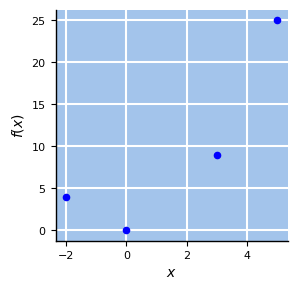

In [23]:
x = np.array([-2, 0, 3, 5])
A = f(x, lambda x: x**2)
print(A)

[['+' '-' '*' '/']
 ['a+b' 'a-b' 'a*b' 'a/b']]


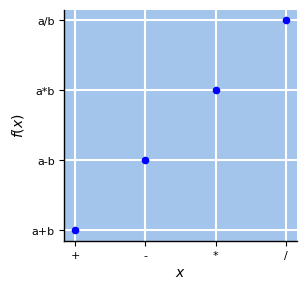

In [24]:
x = np.array(["+", "-", "*", "/"],dtype=str)
A = f(x, lambda x: "a" + x + "b")
print(A)

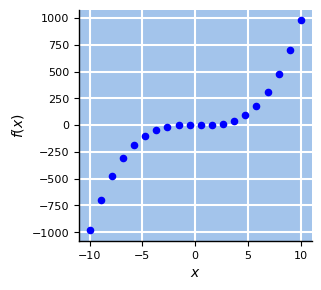

In [25]:
x = np.linspace(-10, 10, 20)
A = f(x, lambda x: x**3 - 2*x - 1)

In [26]:
plt.rcdefaults()

## Exercícios aplicados resolvidos

**I.**  Suponha o seguinte cenário:

Você trabalha com a engenheria de dados responsável pelo painel de atendimento de uma enfermaria pediátrica. O painel gerencia a fila de pacientes, onde cada registro possui o nome da criança e seu peso em quilogramas (kg). Durante o plantão, três eventos ocorrem em sequência:

- Reavaliação (_swap_): o enfermeiro percebe que o segundo e o terceiro paciente da fila têm a mesma classificação de risco, mas o terceiro está com dor aguda. Eles precisam trocar de posição.

- Exame de imagem (_shift): o paciente que está em primeiro lugar na fila precisa ser deslocado para o final, pois foi chamado para um raio-X antes de receber a medicação.

- Prescrição (composição de funções): para a criança que assumiu o primeiro lugar da fila, o sistema deve calcular automaticamente o volume de Paracetamol a ser injetado. A regra médica é de 15 mg por kg de peso, e o frasco disponível tem uma concentração de 50 mg por mL.

O problema: escrever um script que execute o _swap_, o _shift_ e aplique uma função composta para calcular a dosagem final do paciente que encabeça a fila.

In [27]:
from collections import deque

# Estado inicial da fila de pacientes: (nome, peso [kg])
pacientes = [("Ald", 10), ("Bob", 15), ("Cos", 12), ("Dub", 8)]

# Converte para deque para realizar shifts
fila_urgencia = deque(pacientes)

print(f"-- Fila inicial: {list(fila_urgencia)}")

# EVENTO 1: SWAP
fila_urgencia[1], fila_urgencia[2] = fila_urgencia[2], fila_urgencia[1]
print(f"-- Fila após Swap: {list(fila_urgencia)}")

# EVENTO 2: SHIFT
# "Ald" vai para o final da fila fazer o Raio-X. 
# Rotate negativo desloca toda a fila para a esquerda
fila_urgencia.rotate(-1)

print(f"-- Fila após Shift: {list(fila_urgencia)}\n")

# Paciente a ser medicado agora é o índice 0
paciente_atual, peso_atual = fila_urgencia[0]
print(f"-> Próximo paciente: {paciente_atual} ({peso_atual} kg)\n")

# EVENTO 3: COMPOSIÇÃO DE FUNÇÕES

# Função f(x): Peso (kg) -> Dose (mg)
f_calcular_mg = lambda peso: peso * 15

# Função g(x): Dose (mg) -> Volume (mL)
g_calcular_ml = lambda mg: mg / 50

# Função Composta h(x) = g(f(x))
h_prescricao_direta = lambda peso: g_calcular_ml(f_calcular_mg(peso))

# RESULTADO FINAL
volume_final = h_prescricao_direta(peso_atual)

print("## Prescrição Médica")
print(f"Dosagem: {f_calcular_mg(peso_atual)} mg")
print(f"Volume: {volume_final} mL")

-- Fila inicial: [('Ald', 10), ('Bob', 15), ('Cos', 12), ('Dub', 8)]
-- Fila após Swap: [('Ald', 10), ('Cos', 12), ('Bob', 15), ('Dub', 8)]
-- Fila após Shift: [('Cos', 12), ('Bob', 15), ('Dub', 8), ('Ald', 10)]

-> Próximo paciente: Cos (12 kg)

## Prescrição Médica
Dosagem: 180 mg
Volume: 3.6 mL
